# Lesson 1. The environment and the fall

You are going to run a computer version of a bicycle, watch it for a few
seconds, and then look at a graph of how far it leaned. The physics is the
same kind you already use: gravity, speed, and an angle. You do not need to
have built a robot or used this program before.

Work from top to bottom. A gray cell is reading, like the text of a lab
handout. A cell with `[ ]` on the left is something you run: click it and
press Shift+Enter. Wait until `[ ]` becomes a number before you go on. That
number means the cell finished, the way a stopwatch reading means the trial
is over.

## Learning objectives

By the end of this lesson you will be able to:

1. Say what the computer is calculating when it simulates the bicycle.
2. Read a speed plan and state the speed the bicycle was asked to ride.
3. Point to a gain in the configuration and explain, with an example, what that number scales.
4. Match the ride you watched to a graph of lean versus time.

## Glossary

Each word below comes back in the steps. The example is the idea. The later
step is where you use it.

| Term | Meaning | Example |
| --- | --- | --- |
| Simulation | The computer applies the laws of motion over and over, in tiny time steps, and updates where the bicycle is. | The same job as solving F = ma by hand for many small steps, done fast enough to look like motion. |
| MuJoCo | The program that does that physics: gravity, the ground, and the wheels. It does not choose how to steer. | A free-body diagram that is recalculated hundreds of times a second. |
| Model | One particular bicycle inside the simulation: its mass, wheels, and joints. This lesson uses the model named `new_bike`. | The object you drew in the free-body diagram, not the equations themselves. |
| Roll | The lean angle from upright, in degrees. | Stand a book on its edge. The angle it makes as it starts to topple is the roll. 0° is still upright. |
| Controller | A rule that reads a measurement and sends a command to a motor. | Balancing a meter stick on your palm. Your eyes measure the tilt. Your hand moves to catch it. |
| Gain | A number that scales the command. The measurement stays the same. A bigger gain makes a stronger command. | In F = −kx, the stretch x is the measurement and the stiffness k is the gain. |
| Configuration | The list of numbers for this ride, stored in a text file. | The masses and spring constants written at the top of a lab sheet. |
| Reference | The value we are aiming for. The real value can be different. | The temperature you set on an oven. The food is not at that temperature yet. |
| Speed schedule | The plan for how fast the bicycle should move as time passes. | A car speeding up to 2.2 m/s and then holding that speed. The plan does not stop the car from tipping. |


## Step 1. Start the lesson

Run the next cell before anything else.

It finds the project folder and gets the computer ready to draw graphs. The
line `project_root:` is the address of that folder, the way a lab bench has
a room number. You do not need to edit the cell.

If the cell says it cannot find `bike_mujoco_sim`, start Jupyter from the
folder that contains `run_sim.py` and run this cell again.


In [1]:
import os
import sys

def choose_mujoco_gl(platform, display, existing):
    if existing:
        return existing
    if str(platform).startswith("linux") and not display:
        return "egl"
    return None

chosen = choose_mujoco_gl(sys.platform, os.environ.get("DISPLAY"), os.environ.get("MUJOCO_GL"))
if chosen and "MUJOCO_GL" not in os.environ:
    os.environ["MUJOCO_GL"] = chosen

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from dataclasses import replace

from sim.config import load_config
from sim.loop import make_sim, run_headless, summarize
from sim.pid_controller import RollSteerPID, apply_speed_refs

np.set_printoptions(precision=4, suppress=True)
print("project_root:", project_root)
print("platform:", sys.platform, "MUJOCO_GL:", os.environ.get("MUJOCO_GL", "(unset)"))


project_root: /home/lmbike2/bike-workshop/bike_mujoco_sim
platform: linux MUJOCO_GL: egl


## Step 2. Inspect the speed schedule

A speed schedule is a plan, written in advance, for the bicycle's speed at
each moment. Picture a car on a flat road. It starts from rest, speeds up
for a short time, and then the speedometer stays on one number. That plan
says how fast to go. It does not say anything about tipping over sideways.

Here the plan starts at 0 m/s. Over `acceleration_time` seconds it rises to
`target_speed`. After that, the planned speed stays constant. That constant
speed is the cruise speed: the speed after the speed-up is finished, like
the car once the driver has stopped pressing harder on the accelerator.

The wheel that pushes the bicycle forward is the one this plan talks to.
Asking that wheel to spin is like setting cruise control. Cruise control
does not keep a narrow vehicle from falling over.

We print the plan before we watch the bicycle so you can see the request on
its own. Three numbers show up at each time. A reference is the aimed-for
value, like the temperature you dial on an oven. The real temperature can
miss it.

- `speed_ref` is the speed we are aiming for, in meters per second. It should rise, then sit still at cruise.
- `roll_ref` is the lean we are aiming for. It prints as 0, meaning upright.
- `steer_ref` is the handlebar angle we are aiming for. It prints as 0, meaning straight.

Run the next cell. You are done when the speeds climb from 0 toward about
2.2 m/s and then stop climbing, and both `roll_ref` and `steer_ref` print
as 0. Those zeros are the request. They are not a measurement of the
bicycle.


In [2]:
new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(new_bike_yaml)
print("target_speed", cfg.target_speed, "m/s")
print("acceleration_time", cfg.acceleration_time, "s")
for t in (0.0, 0.5, 1.0, cfg.acceleration_time, cfg.acceleration_time + 1.0):
    speed_ref, roll_ref, steer_ref = apply_speed_refs(
        mode="speed-schedule",
        time_s=t,
        speed_goal=None,
        steer_ref=0.0,
        cfg=cfg,
    )
    print(f"t={t:4.2f}s  speed_ref={speed_ref:.3f}  roll_ref={roll_ref}  steer_ref={steer_ref}")


target_speed 2.2 m/s
acceleration_time 1.76 s
t=0.00s  speed_ref=0.000  roll_ref=0.0  steer_ref=0.0
t=0.50s  speed_ref=0.625  roll_ref=0.0  steer_ref=0.0
t=1.00s  speed_ref=1.250  roll_ref=0.0  steer_ref=0.0
t=1.76s  speed_ref=2.200  roll_ref=0.0  steer_ref=0.0
t=2.76s  speed_ref=2.200  roll_ref=0.0  steer_ref=0.0


## Step 3. Let's watch the bike in action

A gain is a multiplier on a command. You already use one in lab. For a
spring, F = −kx. The stretch x is what you measure. The stiffness k decides
how hard the spring pulls for that same stretch. If k is small, the same
stretch produces a weak pull. If k is large, the same stretch produces a
strong pull. k is a gain. It does not measure the stretch. It scales the
force.

On the bicycle, the lean is the measurement, like x. A gain scales how hard
the steering motor reacts to that measurement. The motor is the part that
can actually twist, like the motor in a fan: the rule in the controller
decides, and the motor does the twisting.

The controller is the rule itself. Balancing a meter stick on your palm is
the same kind of rule. Your eyes measure the tilt. Your hand moves to catch
it. "Move your hand harder when the stick is tipping faster" is a controller.
The computer uses a rule like that here. MuJoCo only does the physics, the
way drawing the free-body diagram does not by itself move your hand.

This ride reads its numbers from a configuration file,
`configs/new_bike.yaml`. A configuration is the list at the top of a lab
sheet: masses, times, and the gains. The bicycle object stays the same. These
numbers are what the ride uses. One of them, `pid_kd_roll`, is set to 1 for
this ride. The others stay as written in the file.

`pid_kd_roll` is the gain on how fast the lean is changing, not on how far
the bicycle has already leaned. Picture two bicycles, both leaned over by
5°. One is tipping slowly. One is tipping quickly. The lean angle is the
same, so a gain on the angle treats them alike. `pid_kd_roll` treats them
differently, because one lean is changing faster. Setting that gain to 1
makes the reaction to a fast tip small, the way a small k makes a spring soft.

The other printed names are the same kind of number:

| Name | What it scales |
| --- | --- |
| `target_speed` | The cruise speed, in m/s, after the short speed-up. |
| `acceleration_time` | How many seconds that speed-up lasts. |
| `duration` | How many seconds this ride lasts. |
| `pid_kp_roll` | The gain on how far the bicycle is leaning right now. |
| `pid_ki_roll` | The gain on a lean that has already lasted for a while. |
| `pid_kd_roll` | The gain on how fast the lean is changing. This ride uses 1. |
| `pid_kp_steer` | The gain that tries to bring the handlebars back to straight. |
| `steer_kp`, `steer_ki` | Gains inside the steering motor. Leave them as printed. |

The bicycle is sent off toward a steady cruise speed. It takes
`acceleration_time` to get there. After that, the requested speed stays
constant. The controller is on for the whole ride.

Let's watch the bike in action. You do not need to edit the cell.

1. Run the next cell and read the printed configuration. Check that `pid_kd_roll` is 1 and that the other gains match the file.
2. Watch the bicycle in the window. The window is a picture of the physics you just configured.
3. Close the MuJoCo window. The cell finishes only after that window closes.

If the cell says MuJoCo was already imported, use the menu
**Kernel → Restart Kernel**. That clears the earlier calculation, the way
you clear a lab bench before repeating a trial. Then run this cell again.


In [ ]:
import os
import sys

def find_project_root(start=None):
    current = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(current, "run_sim.py")) and os.path.isfile(
            os.path.join(current, "sim", "__init__.py")
        ):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise RuntimeError(
        "Could not find bike_mujoco_sim. Start Jupyter from the folder that "
        "contains run_sim.py, or from its tutorials folder."
    )

project_root = find_project_root()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

if "mujoco" in sys.modules and os.environ.get("MUJOCO_GL") not in (None, "", "glfw"):
    raise RuntimeError(
        "MuJoCo was already imported with MUJOCO_GL=%r. Restart the kernel, "
        "then run this cell again." % os.environ.get("MUJOCO_GL")
    )
os.environ["MUJOCO_GL"] = "glfw"

from dataclasses import replace
from sim.config import load_config
from sim.loop import make_sim
from sim.viewer import run_viewer

print("project_root:", project_root)
print("MUJOCO_GL:", os.environ.get("MUJOCO_GL"))


new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(new_bike_yaml)
cfg = replace(cfg, pid_kd_roll=1.0, duration=4.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("configuration for this ride")
print(f"  file                 {os.path.relpath(new_bike_yaml, project_root)}")
print(f"  target_speed         {cfg.target_speed} m/s")
print(f"  acceleration_time    {cfg.acceleration_time} s")
print(f"  duration             {cfg.duration} s")
print(f"  pid_kp_roll          {cfg.pid_kp_roll}")
print(f"  pid_ki_roll          {cfg.pid_ki_roll}")
print(f"  pid_kd_roll          {cfg.pid_kd_roll}  (set to 1 for this ride)")
print(f"  pid_kp_steer         {cfg.pid_kp_steer}")
print(f"  steer_kp             {cfg.steer_kp}")
print(f"  steer_ki             {cfg.steer_ki}")
print("Close the MuJoCo window to finish this cell.")
run_viewer(sim)
print("Window closed.")


## Step 4. Draw the lean

The next cell repeats the ride you just watched. It does not open a window.
It records the lean and draws it. Time runs to the right. Lean runs up and
down. The horizontal line at 0° is upright.

Run the cell. When the figure is on the page, read the next gray cell. That
cell is about the line you are looking at.


same ride as the window, pid_kd_roll = 1.0


largest lean during the ride = 117.3 degrees
the lean passed 45 degrees at 0.58 seconds


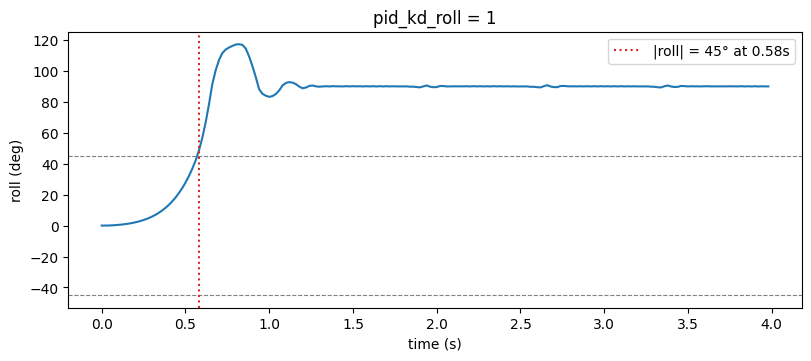

In [4]:
new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(new_bike_yaml)
cfg = replace(cfg, pid_kd_roll=1.0, duration=4.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
print("same ride as the window, pid_kd_roll =", cfg.pid_kd_roll)
history = run_headless(sim, duration=4.0)

time_s = np.asarray(history["time"], dtype=float)
roll_deg = np.degrees(np.asarray(history["roll"], dtype=float))
max_abs = float(np.max(np.abs(roll_deg)))
tip = np.where(np.abs(roll_deg) > 45.0)[0]
tip_t = float(time_s[tip[0]]) if len(tip) else None
print(f"largest lean during the ride = {max_abs:.1f} degrees")
if tip_t is None:
    print("the lean did not pass 45 degrees")
else:
    print(f"the lean passed 45 degrees at {tip_t:.2f} seconds")

fig, ax = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
ax.plot(time_s, roll_deg)
ax.axhline(45.0, color="0.5", linestyle="--", linewidth=0.8)
ax.axhline(-45.0, color="0.5", linestyle="--", linewidth=0.8)
if tip_t is not None:
    ax.axvline(tip_t, color="C3", linestyle=":", label=f"|roll| = 45° at {tip_t:.2f}s")
    ax.legend()
ax.set_xlabel("time (s)")
ax.set_ylabel("roll (deg)")
ax.set_title("pid_kd_roll = 1")
plt.show()

if max_abs < 45.0:
    raise RuntimeError("expected this arbitrary gain to fail")


## The ride, drawn as a line

The curve above is the ride you watched, written down as lean versus time.
The left end is the start. Moving right is later. Up or down is the lean,
the same roll angle as the book tipping on its edge. The title is only the
gain used for this ride, `pid_kd_roll = 1`.

Put a finger on the horizontal line at 0°. That line is upright. A curve
that stays within a few degrees of your finger, roughly between −5° and +5°,
is a bicycle that remained near upright. A curve that moves out through 20°
and on toward 40° is a bicycle that is leaving upright. The sign only says
which side. The size of the number says how far.

The dashed lines at +45° and −45° are this lab's mark for a fall, similar to
calling a meter stick toppled once it has passed 45° from vertical. They are
not a path the bicycle was asked to follow. In Step 2 the request was
`roll_ref = 0`, which is your finger's line, not the dashed lines. If the
curve crosses a dashed line, the lean became a fall by this lab's mark. The
dotted vertical line, if you see one, sits at the first time that happened.
Read that time on the horizontal axis. The sentence under the graph states
the same time in words.

Compare the curve with the window. The window was the motion. This curve is
the lean from that same motion.


## Discussion

### Why did the bicycle tip if a controller was already running?

The controller is the rule that turns a lean measurement into a steering
command, like moving your hand under the meter stick. A moving handlebar
means that rule was doing something. `pid_kd_roll` was 1. For this bicycle
that is a small gain: the same fast tip produces only a weak steering
command, the way a small k in F = −kx produces a weak spring force. The
curve still crossed 45°.

### Why did the speed plan not stop the lean?

The plan only sets how fast the driving wheel should spin, like cruise
control. Cruise control holds a speed. It does not apply the sideways
correction that keeps a narrow vehicle upright. `roll_ref = 0` was the lean
we aimed for, the oven temperature we dialed in. Aiming at 0° does not
create the steering torque that would hold 0°.

### Does the size of that gain matter?

Yes. The bicycle, the speed plan, and the controller rule can stay the same
while `pid_kd_roll` changes. That number is the k in the spring picture. The
questions below ask you to change only that k and compare.


## Questions

Answer these before you change `kd_try`.

1. In Step 2, `roll_ref` was 0 at every printed time. On the curve you just drew, did the lean stay on 0°?
2. This ride used `pid_kd_roll = 1`, and every other gain was left as in the configuration you printed. Predict `pid_kd_roll = 11`, with those other gains unchanged. Does the lean pass 45°, or does it stay under 45°?

Edit `kd_try` and run the cell. Start with `1.0`, the value you already watched. Run it again with `4.0`, then with `11.0`. The cell prints the largest lean. If the lean passed 45°, it also prints the time. If the lean stayed under 45°, it says so. Compare that sentence with what you predicted.


In [5]:
# Edit kd_try, run this cell, then try the next value.
# Trials: 1.0, then 4.0, then 11.0
kd_try = 1.0

new_bike_yaml = os.path.join(project_root, "configs", "new_bike.yaml")
cfg = load_config(new_bike_yaml)
cfg = replace(cfg, pid_kd_roll=float(kd_try), duration=4.0)
sim = make_sim(model_spec="new_bike", mode="speed-schedule", cfg=cfg)
history = run_headless(sim, duration=4.0)
time_s = np.asarray(history["time"], dtype=float)
roll_deg = np.degrees(np.asarray(history["roll"], dtype=float))
max_abs = float(np.max(np.abs(roll_deg)))
tip = np.where(np.abs(roll_deg) > 45.0)[0]
tip_t = float(time_s[tip[0]]) if len(tip) else None
print(f"pid_kd_roll = {cfg.pid_kd_roll}")
print(f"max |roll| = {max_abs:.1f} deg")
if tip_t is None:
    print("Result: held. Roll stayed under 45 deg.")
else:
    print(f"Result: fell at {tip_t:.2f} s. Roll did not stay at 0.")


pid_kd_roll = 1.0
max |roll| = 117.3 deg
Result: fell at 0.58 s. Roll did not stay at 0.
